# **Model Definition**

Import basic **Libraries**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import numpy as np
import matplotlib.pyplot as plt

Import Dataset

In [ ]:
MNIST = keras.datasets.mnist

1. **Normalising** to 0-1 by dividing by 255
2. y_test and y_Train not used anywhere further, because for autoencoders it is not required.

In [ ]:
(x_train, y_train), (x_test, y_test) = MNIST.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

Define the autoencoder

In [ ]:
model = Sequential()

Encoder

In [ ]:
model.add(layers.Dense(25, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(25, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(25, activation='relu'))
model.add(layers.BatchNormalization())


Bottleneck

In [ ]:
model.add(layers.Dense(10, activation='relu'))

Decoder

In [ ]:
model.add(layers.Dense(25, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(25, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(784, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 20)               │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 20)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 20)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 20)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 20)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 10)               │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 20)               │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 20)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 784)              │        16,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 20)               │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 20)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 20)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (32, 20)               │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (32, 10)               │           21

 Total params: 312,014 (1.19 MB)

 Trainable params: 310,364 (1.18 MB)

 Non-trainable params: 1,650 (6.45 KB)

In [ ]:
model.fit(x_train, x_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 22ms/step - loss: 0.0949


# **Anomaly detection**

Using functions for compact use in future
plotRecon plot original and reconstructed

In [ ]:
import matplotlib.pyplot as plt
def plotRecon(img, img_recon):
  plt.subplot(1,2,1)
  plt.title("Original")
  plt.imshow(img.reshape(28,28), cmap="gray")
  plt.axis("off")

  plt.subplot(1,2,2)
  plt.title("Reconstruction")
  plt.imshow(img_recon.reshape(28,28), cmap="gray")
  plt.axis("off")

  plt.show()

1. process the data to match the required model prerequiste
2. Note that : 255 - img --> used for inverting the image to match mnist set (black on white)

In [133]:
def imgProcess(img):
    img = cv2.resize(img, (28, 28))
    img = 255 - img
    img = img / 255.0
    img = img.reshape(1, 784)

    img_recon = model.predict(img)

    error = np.mean((img - img_recon)**2)

    return error,plotRecon(img,img_recon)

Imports malayalam fonts and calls imgProcess function for each

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


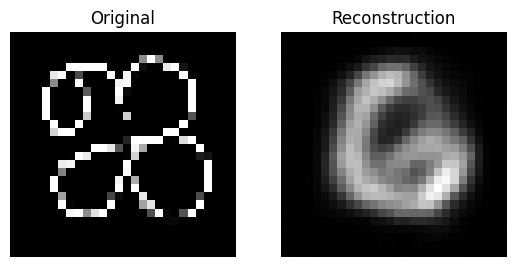

(np.float64(0.09186979480005372), None)


In [132]:
import cv2
import numpy as np

test = cv2.imread("/content/test.png", cv2.IMREAD_GRAYSCALE)
print(imgProcess(test))
